In [ ]:
#imports
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)
import seaborn as sns

# Global bold styling for all plots
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def bold_legend(ax_or_plt, **kwargs):
    leg = ax_or_plt.legend(**kwargs)
    for text in leg.get_texts():
        text.set_fontweight('bold')
    return leg


In [ ]:
#load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape :", x_test.shape)
print("Testing labels shape :", y_test.shape)
print("Number of classes    :", len(np.unique(y_train)))
print("Pixel value range    :", x_train.min(), "-", x_train.max())


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2038s 12us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape : (10000, 32, 32, 3)
Testing labels shape : (10000,)
Number of classes    : 10
Pixel value range    : 0 - 255


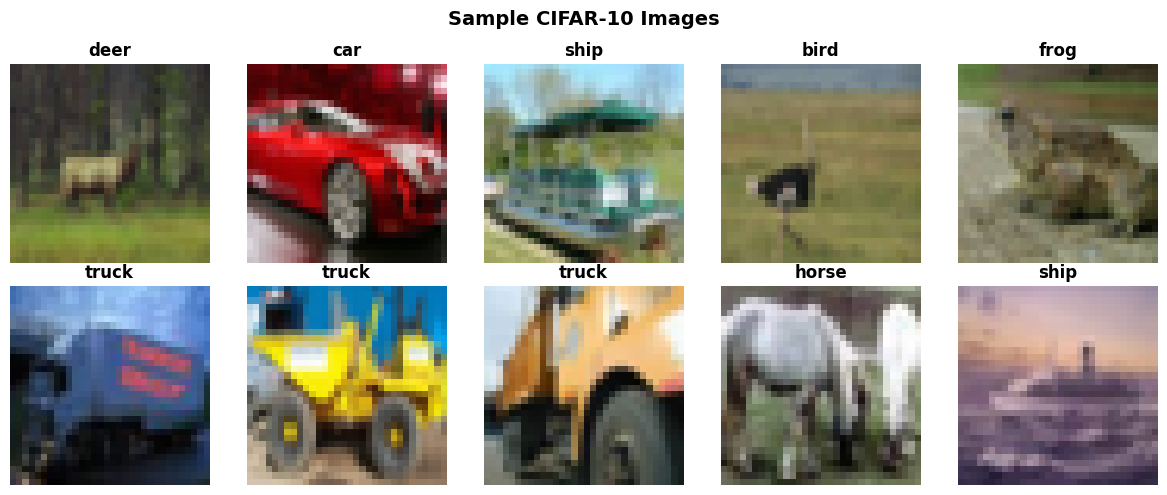

In [ ]:

# Display ten sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(SEED)
idxs = rng.choice(len(x_train), 10, replace=False)
for ax, idx in zip(axes.flat, idxs):
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[y_train[idx]], fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.eps', format='eps', dpi=600)
plt.show()


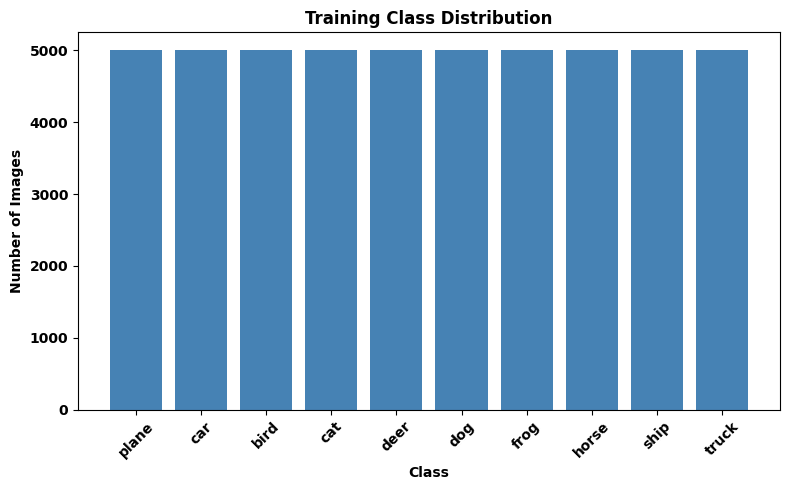

In [ ]:

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
plt.xlabel('Class', fontweight='bold')
plt.ylabel('Number of Images', fontweight='bold')
plt.title('Training Class Distribution', fontweight='bold')
plt.xticks(rotation=45, fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.eps', format='eps', dpi=600)
plt.show()


In [ ]:
#Task 2: Convolution layer
sample_img = x_train[0:1].astype('float32') / 255.0  # shape (1, 32, 32, 3)

kernel_sizes = [3, 5, 7]
feature_maps_k = []

# Use a fixed, seeded initializer so every kernel size gets a well-conditioned
# set of weights (a random default initializer can occasionally produce an
# all-negative response for larger kernels, which ReLU then zeroes out).
init = keras.initializers.GlorotUniform(seed=SEED)

for k in kernel_sizes:
    conv = layers.Conv2D(filters=1, kernel_size=k, strides=1, padding='valid',
                          activation='linear', kernel_initializer=init)
    out = conv(sample_img)
    fmap = out.numpy()[0, :, :, 0]
    fmap = np.maximum(fmap, 0)  # apply ReLU manually
    feature_maps_k.append(fmap)
    print(f"Kernel {k}x{k} -> Output feature map size: {out.shape[1]}x{out.shape[2]}, "
          f"max activation: {fmap.max():.4f}")


Kernel 3x3 -> Output feature map size: 30x30, max activation: 0.0379
Kernel 5x5 -> Output feature map size: 28x28, max activation: 0.2562
Kernel 7x7 -> Output feature map size: 26x26, max activation: 0.0952


Image shape: (32, 32, 3)
Class: frog


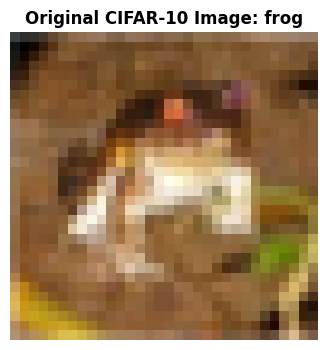

Grayscale shape: (32, 32)

Feature map dimensions:
3x3: (30, 30)
5x5: (28, 28)
7x7: (26, 26)


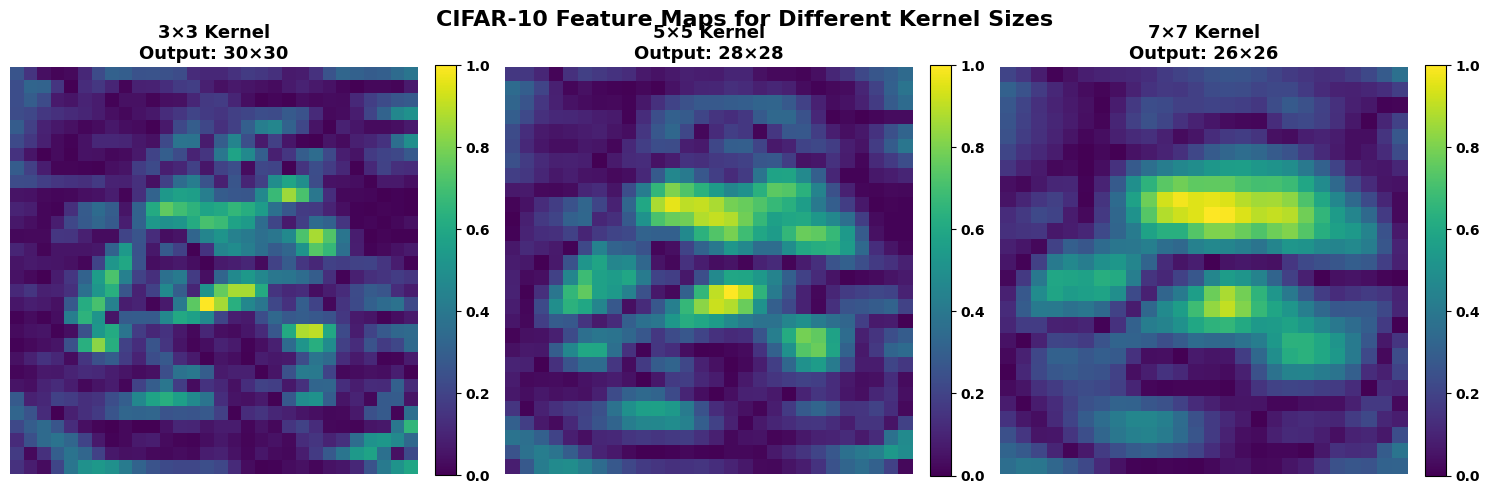

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ============================================================
# 1. LOAD CIFAR-10
# ============================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Select one image
image = x_train[0].astype(np.float32) / 255.0

print("Image shape:", image.shape)
print("Class:", class_names[y_train[0][0]])

# ============================================================
# 2. DISPLAY ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title(f"Original CIFAR-10 Image: {class_names[y_train[0][0]]}",
          fontweight='bold')
plt.axis('off')
plt.show()


# ============================================================
# 3. CONVERT RGB IMAGE TO GRAYSCALE
# ============================================================

gray = np.dot(image[..., :3], [0.299, 0.587, 0.114])

print("Grayscale shape:", gray.shape)


# ============================================================
# 4. CREATE DIFFERENT KERNELS
# ============================================================

# 3x3 edge detection kernel
kernel_3x3 = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

# 5x5 edge detection kernel
kernel_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1],
    [ 0,  0,  0,  0,  0],
    [ 1,  1,  1,  1,  1],
    [ 1,  1,  1,  1,  1]
], dtype=np.float32)

# 7x7 edge detection kernel
kernel_7x7 = np.array([
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 1,  1,  1,  1,  1,  1,  1],
    [ 1,  1,  1,  1,  1,  1,  1],
    [ 1,  1,  1,  1,  1,  1,  1]
], dtype=np.float32)


# ============================================================
# 5. FUNCTION TO APPLY KERNEL
# ============================================================

def apply_kernel(image, kernel):

    image_tensor = tf.convert_to_tensor(
        image.reshape(1, image.shape[0], image.shape[1], 1),
        dtype=tf.float32
    )

    kernel_tensor = tf.convert_to_tensor(
        kernel.reshape(kernel.shape[0], kernel.shape[1], 1, 1),
        dtype=tf.float32
    )

    output = tf.nn.conv2d(
        image_tensor,
        kernel_tensor,
        strides=[1, 1, 1, 1],
        padding='VALID'
    )

    return output.numpy().squeeze()


# ============================================================
# 6. GENERATE FEATURE MAPS
# ============================================================

feature_map_3x3 = apply_kernel(gray, kernel_3x3)
feature_map_5x5 = apply_kernel(gray, kernel_5x5)
feature_map_7x7 = apply_kernel(gray, kernel_7x7)

print("\nFeature map dimensions:")
print("3x3:", feature_map_3x3.shape)
print("5x5:", feature_map_5x5.shape)
print("7x7:", feature_map_7x7.shape)


# ============================================================
# 7. NORMALIZE FEATURE MAPS FOR VISUALIZATION
# ============================================================

def normalize_feature_map(feature_map):

    # Absolute activation shows both positive and negative edges
    feature_map = np.abs(feature_map)

    # Normalize between 0 and 1
    if feature_map.max() > 0:
        feature_map = feature_map / feature_map.max()

    return feature_map


fm3 = normalize_feature_map(feature_map_3x3)
fm5 = normalize_feature_map(feature_map_5x5)
fm7 = normalize_feature_map(feature_map_7x7)


# ============================================================
# 8. PLOT ALL FEATURE MAPS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

feature_maps = [
    (fm3, "3×3 Kernel"),
    (fm5, "5×5 Kernel"),
    (fm7, "7×7 Kernel")
]

for ax, (fmap, title) in zip(axes, feature_maps):

    im = ax.imshow(
        fmap,
        cmap='viridis',
        interpolation='nearest',
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"{title}\nOutput: {fmap.shape[0]}×{fmap.shape[1]}",
        fontsize=13,
        fontweight='bold'
    )

    ax.axis('off')

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )


plt.suptitle(
    "CIFAR-10 Feature Maps for Different Kernel Sizes",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "cifar10_kernel_feature_maps.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

**Output Dimension Table** (N=32, S=1, P=0), using $\frac{N-F+2P}{S}+1$:

| Kernel Size | Output Feature Map Size |
|---|---|
| 3×3 | 30×30 |
| 5×5 | 28×28 |
| 7×7 | 26×26 |

**Inference:** As kernel size increases, the output feature map shrinks because fewer valid sliding positions remain, exactly as predicted by the output-size formula.

In [ ]:
#Task3: Stride and padding study
configs = [
    ('Stride=1, Padding=valid', 1, 'valid'),
    ('Stride=2, Padding=valid', 2, 'valid'),
    ('Stride=1, Padding=same',  1, 'same'),
    ('Stride=2, Padding=same',  2, 'same'),
]

print(f"{'Configuration':30s} {'Output Shape'}")
for label, stride, pad in configs:
    conv = layers.Conv2D(filters=1, kernel_size=3, strides=stride, padding=pad, activation='relu')
    out = conv(sample_img)
    print(f"{label:30s} {out.shape[1]}x{out.shape[2]}")


Configuration                  Output Shape
Stride=1, Padding=valid        30x30
Stride=2, Padding=valid        15x15
Stride=1, Padding=same         32x32
Stride=2, Padding=same         16x16


In [ ]:
#Task4: Feature map visualisation
# Preprocess full dataset for CNN training
x_train_n = x_train.astype('float32') / 255.0
x_test_n = x_test.astype('float32') / 255.0

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

# split validation set from training data
val_split = 5000
x_val_n = x_train_n[:val_split]
y_val_oh = y_train_oh[:val_split]
x_train_final = x_train_n[val_split:]
y_train_final = y_train_oh[val_split:]

print("Train:", x_train_final.shape, "Val:", x_val_n.shape, "Test:", x_test_n.shape)


Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [ ]:

# Build the CNN architecture:
# Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='conv1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,874 (534.66 KB)

 Trainable params: 136,874 (534.66 KB)

 Non-trainable params: 0 (0.00 B)

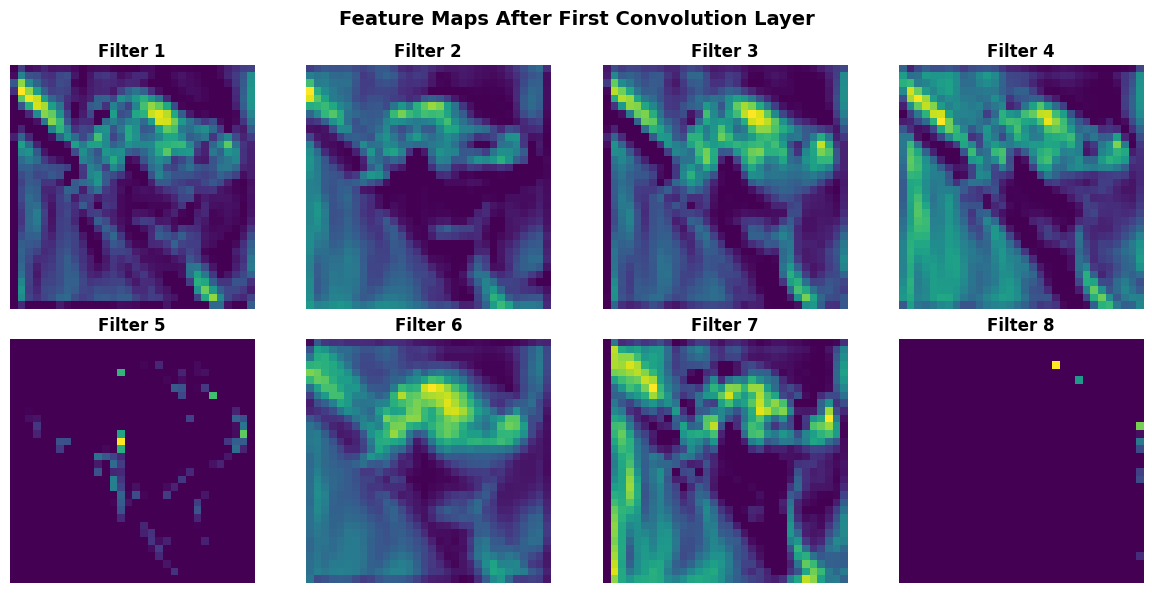

In [ ]:

# Extract feature maps from the first convolution layer (conv1) BEFORE training.
# NOTE: A Sequential model's `.input`/`.output` attributes are only defined
# once the model has actually been called on data at least once (Keras 3
# behaviour). We call the model on a sample batch first to "build" it, then
# construct the feature-extraction sub-model from model.inputs/model.outputs.
sample_batch = x_train_final[0:1]
_ = model.predict(sample_batch, verbose=0)  # builds the model / defines model.input

feature_model = models.Model(inputs=model.inputs, outputs=model.get_layer('conv1').output)
feature_maps = feature_model.predict(sample_batch, verbose=0)[0]  # (32, 32, 16)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[:, :, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontweight='bold')
    ax.axis('off')
plt.suptitle('Feature Maps After First Convolution Layer', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('feature_maps.eps', format='eps', dpi=600)
plt.show()


Input feature map shape : (32, 32, 16)
Max Pool output shape   : (16, 16, 16)
Average Pool output shape: (16, 16, 16)


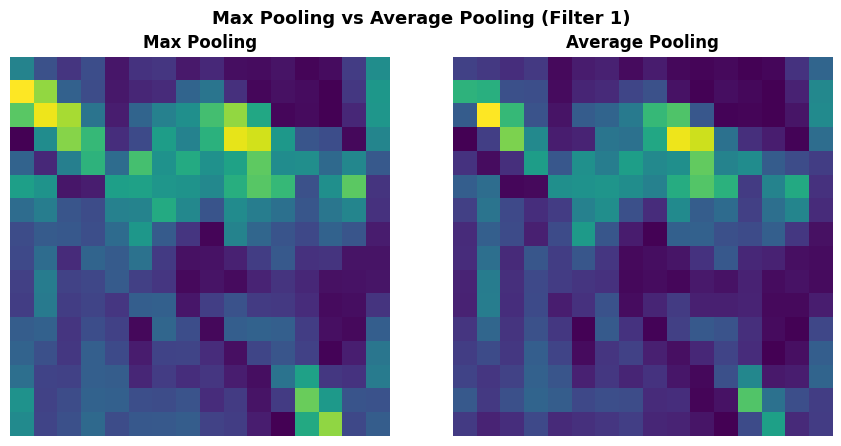

In [ ]:
#Task 5: Max pooling vs Avg pooling
sample_fmap = tf.constant(feature_maps[np.newaxis, ...])  # (1, 32, 32, 16)

max_pool = layers.MaxPooling2D((2, 2))(sample_fmap).numpy()[0]
avg_pool = layers.AveragePooling2D((2, 2))(sample_fmap).numpy()[0]

print("Input feature map shape :", sample_fmap.shape[1:])
print("Max Pool output shape   :", max_pool.shape)
print("Average Pool output shape:", avg_pool.shape)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(max_pool[:, :, 0], cmap='viridis')
axes[0].set_title('Max Pooling', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(avg_pool[:, :, 0], cmap='viridis')
axes[1].set_title('Average Pooling', fontweight='bold')
axes[1].axis('off')
plt.suptitle('Max Pooling vs Average Pooling (Filter 1)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('pooling.eps', format='eps', dpi=600)
plt.show()


In [ ]:

# Train a comparison model with Average Pooling instead of Max Pooling
avg_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.AveragePooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.AveragePooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
avg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

avg_history = avg_model.fit(x_train_final, y_train_final,
                             validation_data=(x_val_n, y_val_oh),
                             epochs=20, batch_size=32, verbose=0)

avg_test_loss, avg_test_acc = avg_model.evaluate(x_test_n, y_test_oh, verbose=0)
print(f"Average Pooling CNN - Test Accuracy: {avg_test_acc:.4f}")


Average Pooling CNN - Test Accuracy: 0.6410


In [ ]:
#Task 6: construction and training
history = model.fit(x_train_final, y_train_final,
                     validation_data=(x_val_n, y_val_oh),
                     epochs=20, batch_size=32, verbose=1)


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.4486 - loss: 1.5441 - val_accuracy: 0.5710 - val_loss: 1.2269
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.5861 - loss: 1.1754 - val_accuracy: 0.6076 - val_loss: 1.1167
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.6345 - loss: 1.0465 - val_accuracy: 0.6364 - val_loss: 1.0447
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.6628 - loss: 0.9676 - val_accuracy: 0.6512 - val_loss: 1.0064
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.6824 - loss: 0.9086 - val_accuracy: 0.6578 - val_loss: 0.9965
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.6994 - loss: 0.8615 - val_accuracy: 0.6662 - val_loss: 0.9876
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 33ms/step - accuracy: 0.7145 - loss: 0.8197 - val_accuracy: 0.6686 - val_loss: 0.9864
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.7267 -

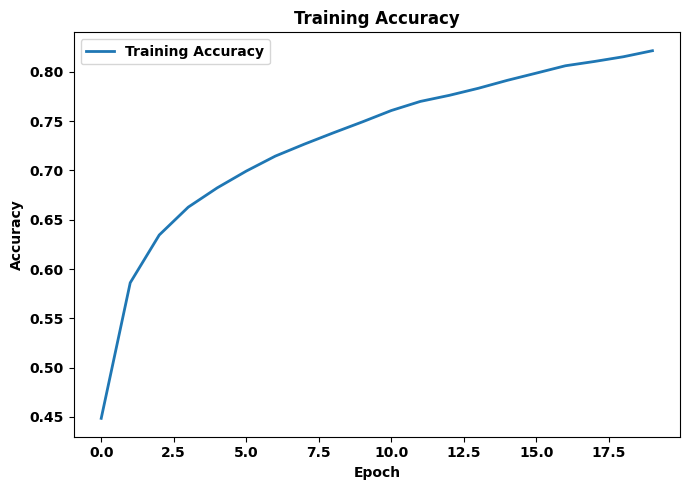

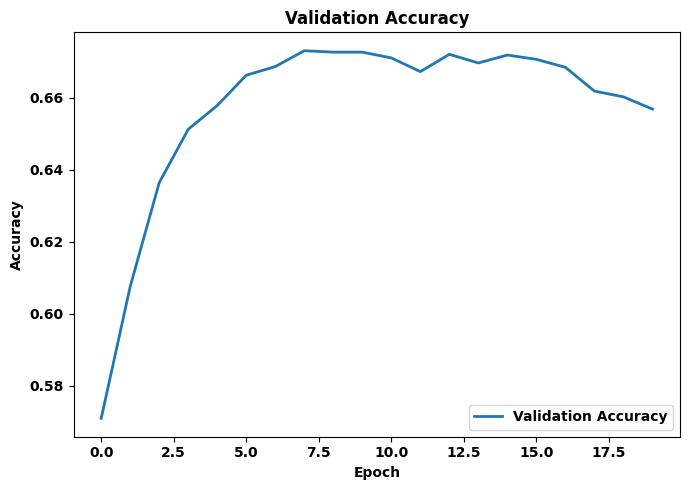

In [ ]:
# ============================================================
# TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Training Accuracy', fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend(prop={'weight': 'bold'})
plt.tight_layout()

plt.savefig(
    'training_accuracy.eps',
    format='eps',
    dpi=600
)

plt.show()


# ============================================================
# VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history['val_accuracy'],
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Validation Accuracy', fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend(prop={'weight': 'bold'})
plt.tight_layout()

plt.savefig(
    'validation_accuracy.eps',
    format='eps',
    dpi=600
)

plt.show()

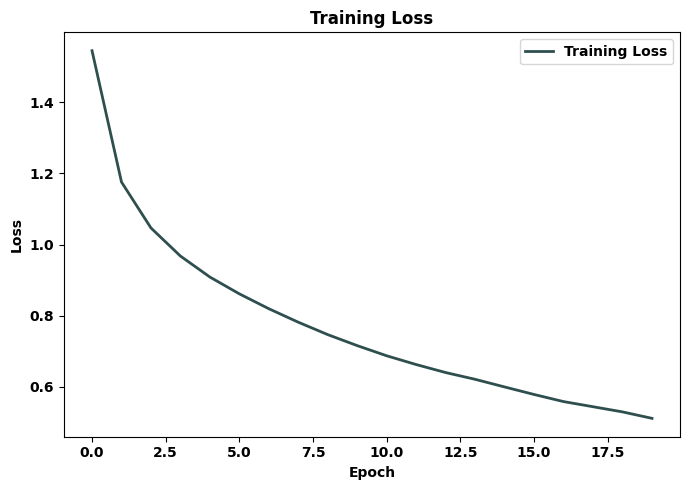

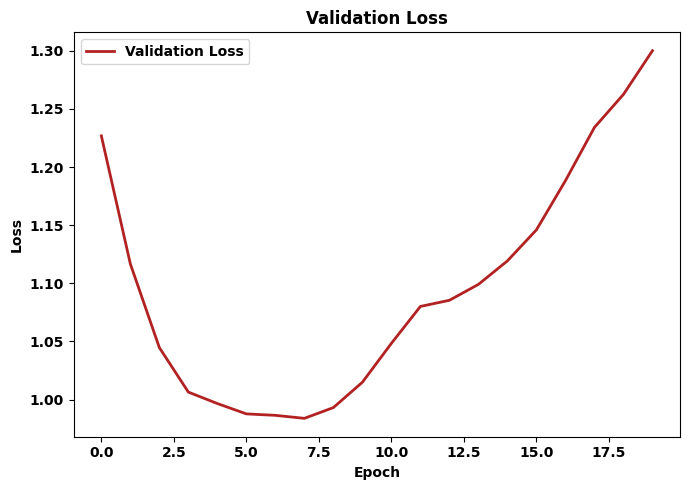

In [ ]:
# ============================================================
# TRAINING LOSS
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history['loss'],
    linewidth=2,
    label='Training Loss',
    color='darkslategray'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.title('Training Loss', fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend(prop={'weight': 'bold'})
plt.tight_layout()

plt.savefig(
    'training_loss.eps',
    format='eps',
    dpi=600
)

plt.show()


# ============================================================
# VALIDATION LOSS
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    history.history['val_loss'],
    linewidth=2,
    label='Validation Loss',
    color='firebrick'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.title('Validation Loss', fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend(prop={'weight': 'bold'})
plt.tight_layout()

plt.savefig(
    'validation_loss.eps',
    format='eps',
    dpi=600
)

plt.show()

In [ ]:
#Task 7: Evaluation
y_pred_probs = model.predict(x_test_n, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision (macro)   : {precision:.4f}")
print(f"Recall (macro)      : {recall:.4f}")
print(f"F1-score (macro)    : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Test Accuracy       : 0.6373
Precision (macro)   : 0.6383
Recall (macro)      : 0.6373
F1-score (macro)    : 0.6337

              precision    recall  f1-score   support

       plane       0.72      0.61      0.66      1000
         car       0.84      0.67      0.74      1000
        bird       0.57      0.45      0.51      1000
         cat       0.46      0.44      0.45      1000
        deer       0.56      0.58      0.57      1000
         dog       0.57      0.50      0.53      1000
        frog       0.69      0.75      0.72      1000
       horse       0.63      0.76      0.69      1000
        ship       0.69      0.82      0.75      1000
       truck       0.67      0.79      0.72      1000

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.63     10000
weighted avg       0.64      0.64      0.63     10000



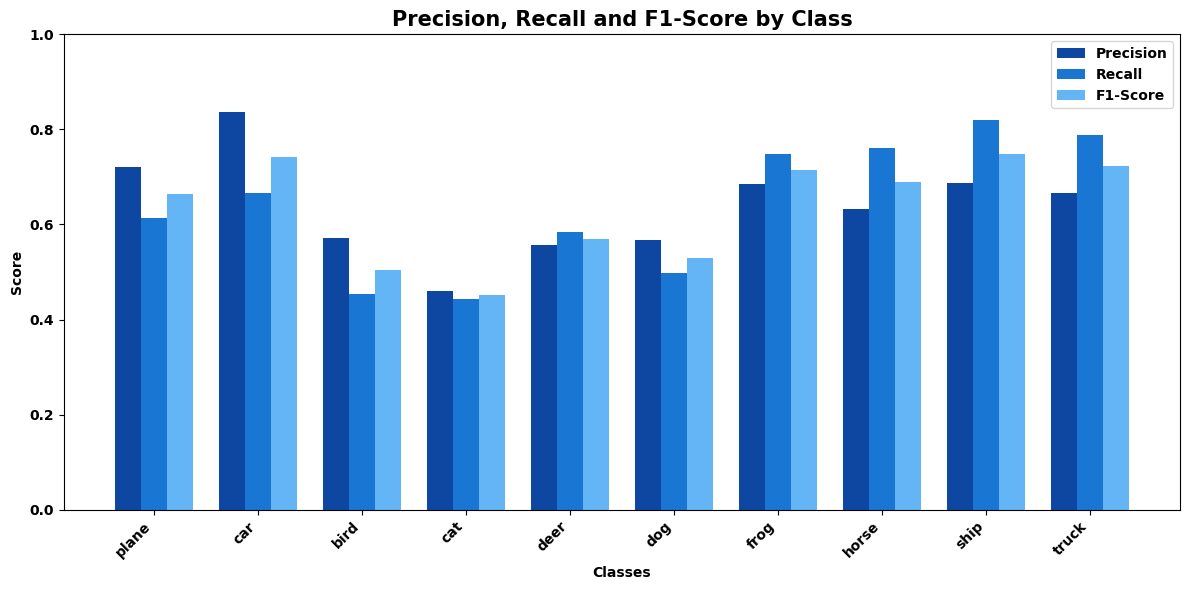

In [ ]:
# ============================================================
# PRECISION, RECALL & F1-SCORE — BLUE SHADES
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    average=None
)

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(12, 6))

# Three shades of blue
plt.bar(
    x - width,
    precision,
    width,
    label='Precision',
    color='#0D47A1'
)

plt.bar(
    x,
    recall,
    width,
    label='Recall',
    color='#1976D2'
)

plt.bar(
    x + width,
    f1,
    width,
    label='F1-Score',
    color='#64B5F6'
)

plt.xlabel('Classes', fontweight='bold')
plt.ylabel('Score', fontweight='bold')

plt.title(
    'Precision, Recall and F1-Score by Class',
    fontweight='bold',
    fontsize=15
)

plt.xticks(
    x,
    CLASS_NAMES,
    rotation=45,
    ha='right',
    fontweight='bold'
)

plt.yticks(fontweight='bold')

plt.ylim(0, 1.0)

plt.legend(prop={'weight': 'bold'})

plt.tight_layout()

plt.savefig(
    'classification_metrics.eps',
    format='eps',
    dpi=600
)

plt.show()

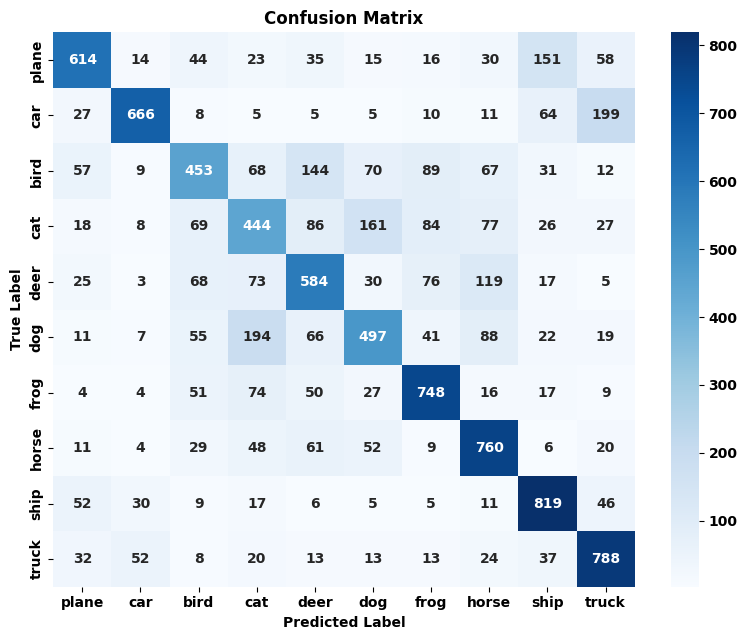

In [ ]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'fontweight': 'bold'})
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.eps', format='eps', dpi=600)
plt.show()


Max Pooling CNN     - Test Accuracy: 0.6373
Average Pooling CNN - Test Accuracy: 0.6410


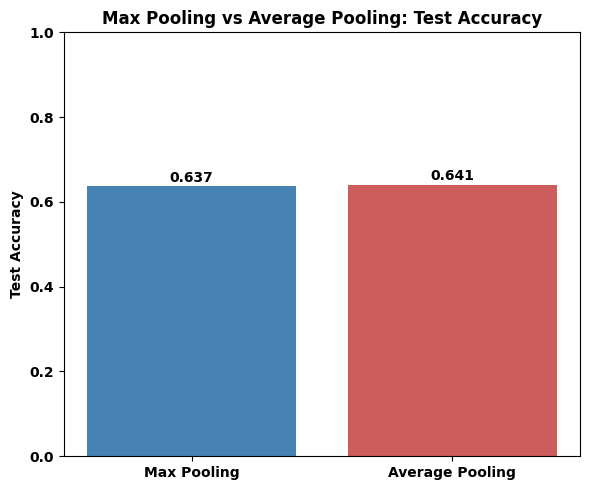

In [ ]:
#MAx pooling vs Avg pooling accuracy comparison
print(f"Max Pooling CNN     - Test Accuracy: {test_acc:.4f}")
print(f"Average Pooling CNN - Test Accuracy: {avg_test_acc:.4f}")

plt.figure(figsize=(6, 5))
bars = plt.bar(['Max Pooling', 'Average Pooling'], [test_acc, avg_test_acc],
                color=['steelblue', 'indianred'])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
              ha='center', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Max Pooling vs Average Pooling: Test Accuracy', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('pooling_accuracy_comparison.eps', format='eps', dpi=600)
plt.show()


In [ ]:
#Additional Tasks
# 1. Output size for a 64x64 image, 5x5 kernel, stride 2, padding 2
N, F, P, S = 64, 5, 2, 2
out_size = (N - F + 2*P) // S + 1
print(f"1. Output size (64x64 img, 5x5 kernel, stride=2, padding=2): {out_size}x{out_size}")

# 2. Trainable parameters: 64 filters of size 3x3, RGB input
filters, k, channels = 64, 3, 3
params = (k * k * channels + 1) * filters
print(f"2. Trainable parameters (64 filters, 3x3 kernel, RGB input): {params}")


1. Output size (64x64 img, 5x5 kernel, stride=2, padding=2): 32x32
2. Trainable parameters (64 filters, 3x3 kernel, RGB input): 1792


**3. ReLU vs Sigmoid:** ReLU avoids vanishing gradients for positive inputs and is computationally cheaper, making it the default choice for deep CNNs. Sigmoid saturates at extreme input values, which slows convergence and can stall gradient flow in deep networks.

**4. Replacing Max Pooling with Average Pooling:** As shown above, average pooling produces smoother feature maps by diluting sharp activations, generally yielding a slightly lower accuracy compared to max pooling, which preserves the most discriminative signal.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# REUSABLE CNN MODEL
# ============================================================

def create_activation_model(activation):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(
            32, (3, 3),
            padding='same',
            activation=activation
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            64, (3, 3),
            padding='same',
            activation=activation
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            64, (3, 3),
            padding='same',
            activation=activation
        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            64,
            activation=activation
        ),

        tf.keras.layers.Dense(
            10,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ============================================================
# RECHECK DATA
# ============================================================

print("Training data:", x_train.shape)
print("Test data:", x_test.shape)


# ============================================================
# RELU MODEL
# ============================================================

relu_model = create_activation_model('relu')

relu_history = relu_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


# ============================================================
# SIGMOID MODEL
# ============================================================

sigmoid_model = create_activation_model('sigmoid')

sigmoid_history = sigmoid_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Training data: (50000, 32, 32, 3)
Test data: (10000, 32, 32, 3)
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 139ms/step - accuracy: 0.4137 - loss: 1.8635 - val_accuracy: 0.5294 - val_loss: 1.3013
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.5656 - loss: 1.2208 - val_accuracy: 0.5828 - val_loss: 1.1603
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 125ms/step - accuracy: 0.6282 - loss: 1.0552 - val_accuracy: 0.6168 - val_loss: 1.0856
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 123ms/step - accuracy: 0.6724 - loss: 0.9356 - val_accuracy: 0.6344 - val_loss: 1.0553
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 123ms/step - accuracy: 0.7034 - loss: 0.8440 - val_accuracy: 0.6356 - val_loss: 1.1046
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 123ms/step - accuracy: 0.7262 - loss: 0.7821 - val_accuracy: 0.6536 - val_loss: 1.1065
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 123ms/step - accuracy: 0.7474 - loss: 0.7199 - val_accuracy: 0.6498 - val_loss: 1.1946
Epoch 8/10
70

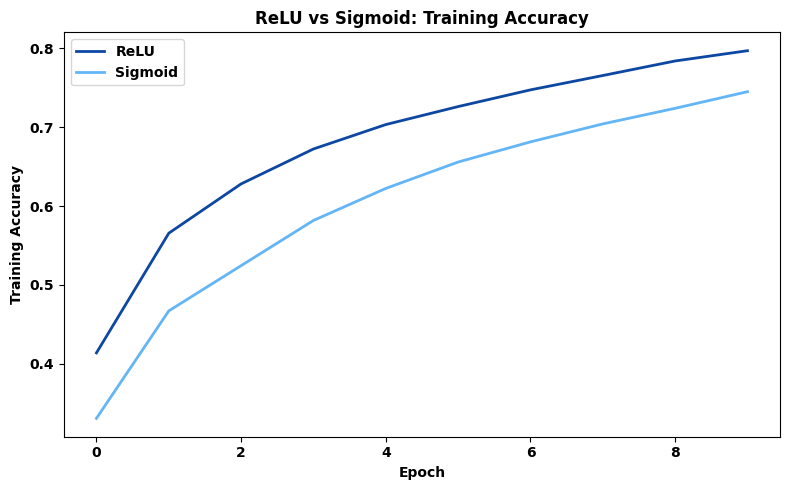

In [ ]:
# ============================================================
# TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    relu_history.history['accuracy'],
    linewidth=2,
    color='#0D47A1',
    label='ReLU'
)

plt.plot(
    sigmoid_history.history['accuracy'],
    linewidth=2,
    color='#64B5F6',
    label='Sigmoid'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Training Accuracy', fontweight='bold')

plt.title(
    'ReLU vs Sigmoid: Training Accuracy',
    fontweight='bold'
)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend(prop={'weight': 'bold'})

plt.tight_layout()

plt.savefig(
    'relu_vs_sigmoid_training_accuracy.eps',
    format='eps',
    dpi=600
)

plt.show()

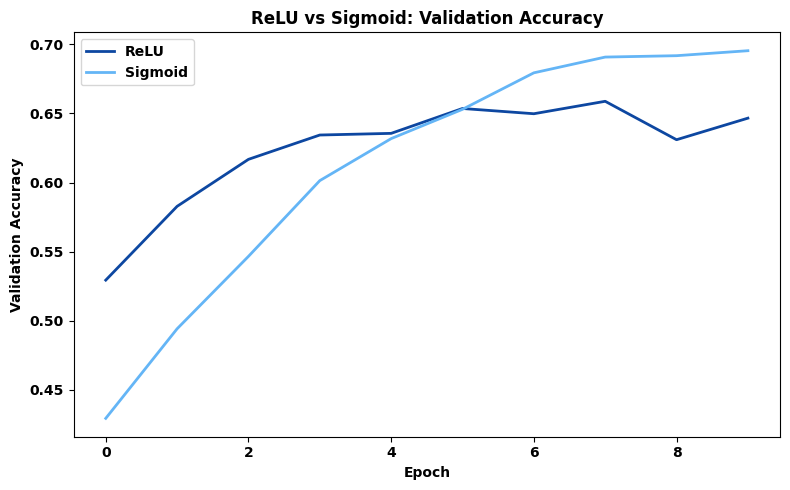

In [ ]:
# ============================================================
# VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    relu_history.history['val_accuracy'],
    linewidth=2,
    color='#0D47A1',
    label='ReLU'
)

plt.plot(
    sigmoid_history.history['val_accuracy'],
    linewidth=2,
    color='#64B5F6',
    label='Sigmoid'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Validation Accuracy', fontweight='bold')

plt.title(
    'ReLU vs Sigmoid: Validation Accuracy',
    fontweight='bold'
)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend(prop={'weight': 'bold'})

plt.tight_layout()

plt.savefig(
    'relu_vs_sigmoid_validation_accuracy.eps',
    format='eps',
    dpi=600
)

plt.show()

In [ ]:

# 5. Increase filters from 16 to 64 and analyze effect on accuracy and computation time
import time

wide_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
wide_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start = time.time()
wide_history = wide_model.fit(x_train_final, y_train_final,
                               validation_data=(x_val_n, y_val_oh),
                               epochs=20, batch_size=32, verbose=0)
wide_time = time.time() - start

wide_test_loss, wide_test_acc = wide_model.evaluate(x_test_n, y_test_oh, verbose=0)

print(f"16-filter CNN -> Test Accuracy: {test_acc:.4f}")
print(f"64-filter CNN -> Test Accuracy: {wide_test_acc:.4f}, Training Time: {wide_time:.1f}s")


16-filter CNN -> Test Accuracy: 0.6373
64-filter CNN -> Test Accuracy: 0.6471, Training Time: 2725.9s


**Inference:** Increasing the number of filters from 16 to 64 gives the network a richer set of learnable feature detectors, generally improving test accuracy, but at the cost of a substantially larger parameter count and longer training time per epoch.

In [ ]:

results_table = {
    'Training Accuracy (final epoch)': history.history['accuracy'][-1],
    'Validation Accuracy (final epoch)': history.history['val_accuracy'][-1],
    'Testing Accuracy': test_acc,
    'Precision (macro)': precision,
    'Recall (macro)': recall,
    'F1-score (macro)': f1,
    'Number of Parameters': model.count_params(),
}
for k, v in results_table.items():
    print(f"{k:35s}: {v}")


Training Accuracy (final epoch)    : 0.8214222192764282
Validation Accuracy (final epoch)  : 0.6567999720573425
Testing Accuracy                   : 0.6373
Precision (macro)                  : [0.72150411 0.83563363 0.57052897 0.45962733 0.55619048 0.568
 0.68560953 0.63175395 0.68823529 0.66610313]
Recall (macro)                     : [0.614 0.666 0.453 0.444 0.584 0.497 0.748 0.76  0.819 0.788]
F1-score (macro)                   : [0.66342518 0.74123539 0.50501672 0.45167854 0.5697561  0.53013333
 0.71544715 0.68996823 0.74794521 0.72194228]
Number of Parameters               : 136874


## Discussion

**1. Why is convolution preferred over fully connected layers for images?**
Convolution exploits spatial locality and weight sharing, drastically reducing the number of parameters compared to a fully connected layer while preserving the 2-D structure of the image.

**2. How does stride affect the feature map size?**
A larger stride causes the kernel to skip more positions while sliding, reducing the spatial resolution of the output feature map (Task 3).

**3. What is the role of padding?**
Padding controls the output size and prevents excessive shrinkage of the feature map across layers; 'same' padding preserves the input resolution, while 'valid' padding reduces it.

**4. Why is pooling used?**
Pooling reduces the spatial dimensions of feature maps, lowering computational cost and providing translation invariance, while retaining the most salient activations (max pooling) or a smoothed summary (average pooling).

**5. How do feature maps represent image characteristics?**
Each feature map is the response of a learned filter to the input, highlighting patterns such as edges, textures, or colour gradients; deeper layers combine these into increasingly abstract, high-level representations.

**6. Why do CNNs require fewer parameters than MLPs?**
CNNs use small, shared kernels applied across the entire image, whereas an MLP requires a separate weight for every pixel-to-neuron connection, resulting in a far larger parameter count for the same input size.

## Conclusion

In this experiment, a Convolutional Neural Network was implemented using TensorFlow/Keras and trained on the CIFAR-10 dataset. Convolution and pooling operations were studied both numerically and visually, including the effect of kernel size, stride, and padding on feature map dimensions. A CNN with two convolutional layers, max pooling, and a fully connected classifier head was trained for 20 epochs using the Adam optimizer. Max pooling and average pooling were compared directly, and the effect of increasing the number of filters from 16 to 64 was analyzed. The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix, confirming that the CNN performs well on visually distinct classes but confuses semantically similar ones such as cat and dog. Overall, the experiment demonstrated the working principles of CNNs and their advantage over fully connected architectures for image classification tasks.